# **EXPERIMENT-9** -Car Evaluation Dataset

**AIM:** To implement an Ensemble Learning model using Random Forest Classifier on the Car Evaluation dataset to predict the acceptability of cars based on various features (buying price, maintenance cost, doors, persons capacity, luggage boot size, and safety), and to evaluate the model using accuracy, OOB score, confusion matrix, cross-validation, and feature importance.

In [3]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
# Step 2: Load dataset
from google.colab import drive
drive.mount('/content/drive')
df=pd.read_csv('/content/drive/MyDrive/Datasets/car evaluation.csv')


Mounted at /content/drive


**Manually assign column**
* This dataset doesn’t have proper column names, so we manually assign them.
* class is the target variable (what we want to predict).
* Other columns are features (input variables).

In [5]:
## Step 3: Manually assign column names (because in this dataset 1st row is treated as column names)
df.columns = [
    "buying",
    "maint",
    "doors",
    "persons",
    "lug_boot",
    "safety",
    "class"
]

print("Columns are:\n", df.columns)
print("\nFirst 5 rows:\n", df.head())



Columns are:
 Index(['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class'], dtype='object')

First 5 rows:
   buying  maint  doors  persons lug_boot safety  class
0  vhigh  vhigh      2        2    small   high  unacc
1  vhigh  vhigh      2        2      med    low  unacc
2  vhigh  vhigh      2        2      med    med  unacc
3  vhigh  vhigh      2        2      med   high  unacc
4  vhigh  vhigh      2        2      big    low  unacc


In [6]:
# Step 4: Check missing values
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64


**Feature Scaling**
* Random Forest cannot handle text directly, it needs numbers.
* LabelEncoder converts each category into a number:
* Example: buying → {"low":0, "med":1, "high":2, "vhigh":3}

In [7]:
# Step 5:Feature scaling
encoders = {}

for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

print("\nEncoded Sample:\n", df.head())


Encoded Sample:
    buying  maint  doors  persons  lug_boot  safety  class
0       3      3      0        0         2       0      2
1       3      3      0        0         1       1      2
2       3      3      0        0         1       2      2
3       3      3      0        0         1       0      2
4       3      3      0        0         0       1      2


* X → Input features for prediction.
* y → Output/target (car class).
* iloc[:, :-1] → selects all rows, all columns except last.
* iloc[:, -1] → selects all rows, last column.

In [8]:
# Step 6:Train- Test split
X = df.iloc[:, :-1]   # take all columns except last
y = df.iloc[:, -1]    # take last column as target

* Train set → used to train the model (80%).
* Test set → used to evaluate the model (20%).
* stratify=y ensures each class is proportionally represented in both sets.
* random_state=42 ensures reproducibility.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


**Initialize RandomForest Model**
* n_estimators=300 → Number of decision trees in the forest. More trees → better accuracy.
* max_depth=None → Trees grow fully until leaves are pure or have few samples.
* bootstrap=True → Random samples with replacement are used to train each tree.
* oob_score=True → Out-of-bag score, a way to evaluate without using a test set.
* class_weight='balanced' → Handles imbalanced classes automatically.
* random_state=42 → Ensures consistent results.
* n_jobs=-1 → Use all CPU cores for faster training.
* fit() trains the Random Forest using the training data.

In [10]:
# Step 7:Model Implementation
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    bootstrap=True,
    oob_score=True,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       oob_score=True, random_state=42)

**Model Prediction and Evaluation**
* Random Forest builds many decision trees on random subsets of data/features.
* Each tree votes for the class, and majority vote is taken as the final prediction.
* OOB Score is a quick estimate of model accuracy using samples not included in each tree.

In [11]:
# Step 8:Model Prediction and Evaluation
print("\nOOB Score:", rf.oob_score_)


OOB Score: 0.9746376811594203


* predict() predicts the class for test data.

* accuracy_score() → Percentage of correctly predicted samples.

* confusion_matrix() → Shows true vs predicted classes in a table:

   * Rows → actual class

   * Columns → predicted class

* classification_report() → Provides:

   * Precision → Accuracy of positive predictions.

   * Recall → Ability to find all positive samples.

   * F1-score → Balance between precision and recall.

In [12]:
y_pred = rf.predict(X_test)

print("\nFirst 20 Predictions:", y_pred[:20])
print("\nActual Values:", y_test[:20].values)


First 20 Predictions: [1 2 2 2 0 2 2 0 2 2 2 2 2 2 3 2 0 2 2 2]

Actual Values: [1 2 2 2 0 2 2 0 2 2 2 2 2 2 3 2 0 2 2 2]


In [13]:

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Test Accuracy: 0.9884393063583815

Confusion Matrix:
 [[ 75   1   1   0]
 [  1  13   0   0]
 [  0   0 242   0]
 [  1   0   0  12]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        77
           1       0.93      0.93      0.93        14
           2       1.00      1.00      1.00       242
           3       1.00      0.92      0.96        13

    accuracy                           0.99       346
   macro avg       0.97      0.96      0.97       346
weighted avg       0.99      0.99      0.99       346



* Cross-validation splits the dataset into 5 folds.
* Each fold is used as test once, rest as training.
* Provides a robust estimate of model performance across the entire dataset.
* cv_scores.mean() gives average accuracy.

In [14]:
# STEP 9: Cross Validation

cv_scores = cross_val_score(rf, X, y, cv=5)
print("\nCross Validation Accuracy:", cv_scores.mean())



Cross Validation Accuracy: 0.8013822568484542


* Random Forest can tell us which features are most important in prediction.
* feature_importances_ → A score for each feature (higher → more influence).
* Plotting gives a visual idea of which features matter most.

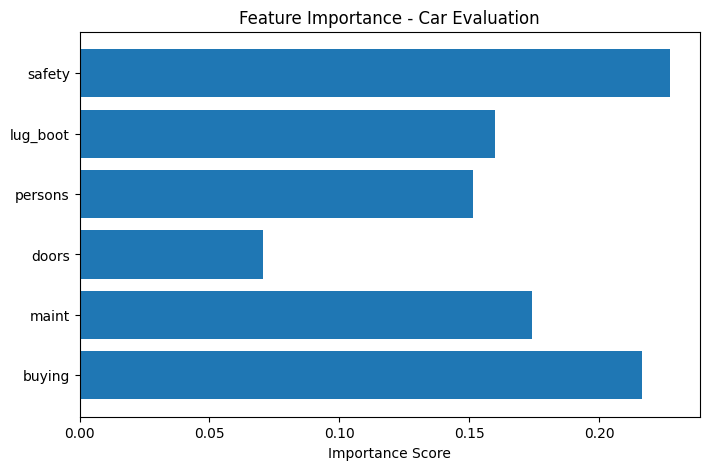

In [15]:
# STEP 10: Feature Importance

importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
plt.barh(features, importances)
plt.xlabel("Importance Score")
plt.title("Feature Importance - Car Evaluation")
plt.show()

Random Forest is a powerful ensemble method for classification.
Works well on the Car Evaluation dataset, giving high accuracy and robust predictions.
Key features such as safety, buying, and maint play a major role in predicting car acceptability.